#### Assignment 2
**Mahshid Bargahi**

On this notebook we use **Ames Housing dataset**, which contains information about residential homes sold in Ames, Iowa.  

The goal of this project is to build a **Binary Classification model** that predicts whether a house is Expensive or Normal.
The model uses various house features (area, quality, amenities, neighborhood, etc.) to predict if the house price is above the median price or not.

## Libraries

In [1]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

## Loading dataset

This dataset is the cleaned and feature‑engineered version from Assignment 1. Missing values were handled, useless columns removed, and new features (ratios, binning, date/time transformations, aggregations, and log transforms) were created.  All categorical variables were encoded.

In [2]:
data  = pd.read_csv(r'D:\sharif\ADS\assignments\assignment2\AmesHousing_Encoded_Final.csv')
data.head()

,MS SubClass,Lot Frontage,Lot Area,Land Slope,Condition 1,Condition 2,Overall Qual,Overall Cond,Year Remod/Add,Mas Vnr Area,...,Garage Type_None,Sale Type_CWD,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD
0,20,141.0,31770,1,6,5,6,5,1960,112.0,...,0,0,0,0,0,0,0,0,0,1
1,20,80.0,11622,1,4,5,5,6,1961,1.0,...,0,0,0,0,0,0,0,0,0,1
2,20,81.0,14267,1,6,5,6,6,1958,108.0,...,0,0,0,0,0,0,0,0,0,1
3,20,93.0,11160,1,6,5,7,5,1968,1.0,...,0,0,0,0,0,0,0,0,0,1
4,60,74.0,13830,1,6,5,5,5,1998,1.0,...,0,0,0,0,0,0,0,0,0,1


### Creating Binary Target

- Target Column: IsExpensive

- Value 1: Houses with price above the median (SalePrice > median)

- Value 0: Houses with price below or equal to the median


(Using the median creates balanced classes (approximately 50/50) and is robust against outliers.)

In [3]:
threshold = data['SalePrice'].median()
data['IsExpensive'] = (data['SalePrice'] > threshold).astype(int)

data['IsExpensive'].head()

0    1
1    0
2    1
3    1
4    1
Name: IsExpensive, dtype: int64

### Removing Data Leakage Features
To prevent the model from cheating, features that are directly or indirectly derived from SalePrice must be removed.

In [4]:
price_columns = [col for col in data.columns if 'price' in col.lower()]
print(price_columns)

['SalePrice', 'Neighborhood_AvgPrice', 'Zone_AvgPrice', 'SaleType_AvgPrice']


In [5]:
data = data.drop(columns=price_columns)

## Preprocessing

In [6]:
X = data.drop('IsExpensive', axis=1)
y = data['IsExpensive']

print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts(normalize=True)}")

X shape: (2854, 170)
y distribution:
IsExpensive
0    0.502102
1    0.497898
Name: proportion, dtype: float64


- The target is well balanced (≈50/50), which is good for classification.


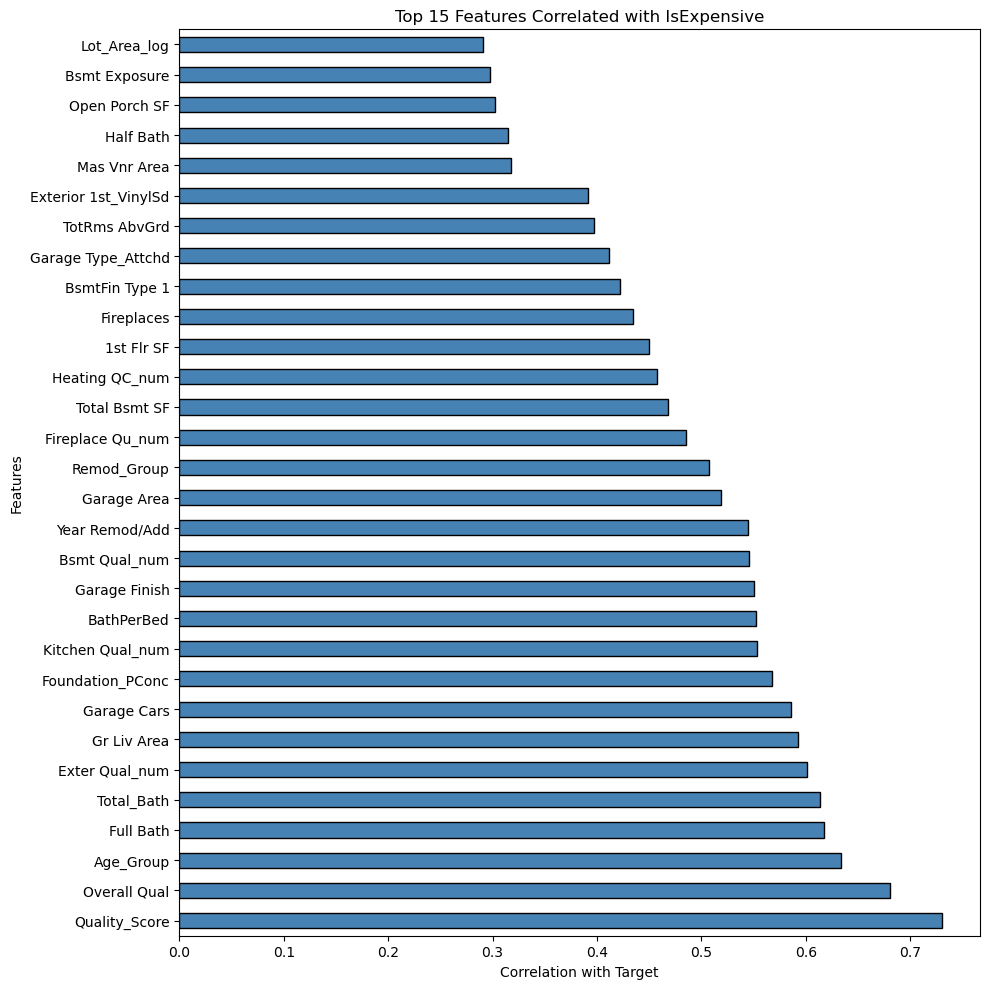

In [7]:
corr_with_target = X.corrwith(y).sort_values(ascending=False)

plt.figure(figsize=(10, 10))
corr_with_target.head(30).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Features Correlated with IsExpensive')
plt.xlabel('Correlation with Target')
plt.ylabel('Features')
plt.tight_layout()
plt.show() 

- Correlation analysis confirms that quality and size features are the strongest predictors of being expensive.

### Preparing Train and Test Sets

In [8]:
from sklearn.model_selection import train_test_split

# stratify=y to preserve class balance.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)

(2283, 170)
(571, 170)


### Scaling 

**Scale** features using StandardScaler
   - fit on training set only
   - transform on both training and test sets


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Modeling

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_binary_model(model_name, y_real, y_pred, y_proba=None):
    acc = accuracy_score(y_real, y_pred)
    prec = precision_score(y_real, y_pred)
    rec = recall_score(y_real, y_pred)
    f1 = f1_score(y_real, y_pred)
    auc = roc_auc_score(y_real, y_proba) if y_proba is not None else None
    
    print(f" {model_name:20}  Accuracy : {acc:.4f} | Precision: {prec:.4f} | Recall : {rec:.4f} | F1 Score : {f1:.4f}")
    
    if auc:
        print(f"AUC   : {auc:.4f}")
    
    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC': auc}

### Logistic Regression



In [15]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=100, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_performance = evaluate_binary_model("Logistic Regression", y_test, y_pred_lr)


 Logistic Regression   Accuracy : 0.9370 | Precision: 0.9397 | Recall : 0.9331 | F1 Score : 0.9364


Let's check model with several C valus

In [17]:
# tuning C (inverse of regularization strength) ,  increase max_iter
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

for C in C_values:
    lr = LogisticRegression(C=C , max_iter=200, random_state=42)
    lr.fit(X_train, y_train)
    f1 = f1_score(y_test, lr.predict(X_test))
    print(f"C={C:6} → F1 = {f1:.4f}")

C= 0.001 → F1 = 0.9378
C=  0.01 → F1 = 0.9399
C=   0.1 → F1 = 0.9366
C=   1.0 → F1 = 0.9364
C=  10.0 → F1 = 0.9326
C= 100.0 → F1 = 0.9343


We tested C values from 0.001 to 100.0.  
The best F1 score (0.94) was achieved at C = 0.01

We chose C = 0.01 because:
- It provides strong enough regularization to prevent overfitting.
- Performance is nearly identical to the best observed score.

In [98]:
lr_model = LogisticRegression(C=0.01, max_iter=100, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

y_proba_lr = lr_model.predict_proba(X_test)[:, 1]
lr_performance = evaluate_binary_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr)


 Logistic Regression   Accuracy : 0.9405 | Precision: 0.9433 | Recall : 0.9366 | F1 Score : 0.9399
AUC   : 0.9846


##### Log Loss (Cross-Entropy)

Log Loss (Cross-Entropy Loss) measures the uncertainty of predictions.  

Lower values indicate that the model is both **correct** and **confident** about its predictions.

In [99]:
from sklearn.metrics import log_loss

print(log_loss(y_test, y_proba_lr))

0.1634751184871589


Our Logistic Regression achieved **0.16**, which means it makes confident and accurate predictions.

### SVM (Linear)

In [25]:
from sklearn.svm import SVC
svm_model = SVC(C=1, kernel='linear', max_iter=1000)   
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

svm_performance = evaluate_binary_model("SVM (Linear)", y_test, y_pred_svm)

 SVM (Linear)          Accuracy : 0.8669 | Precision: 0.8741 | Recall : 0.8556 | F1 Score : 0.8648


c:\Users\kavoshrayan\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


getting some insight about weights

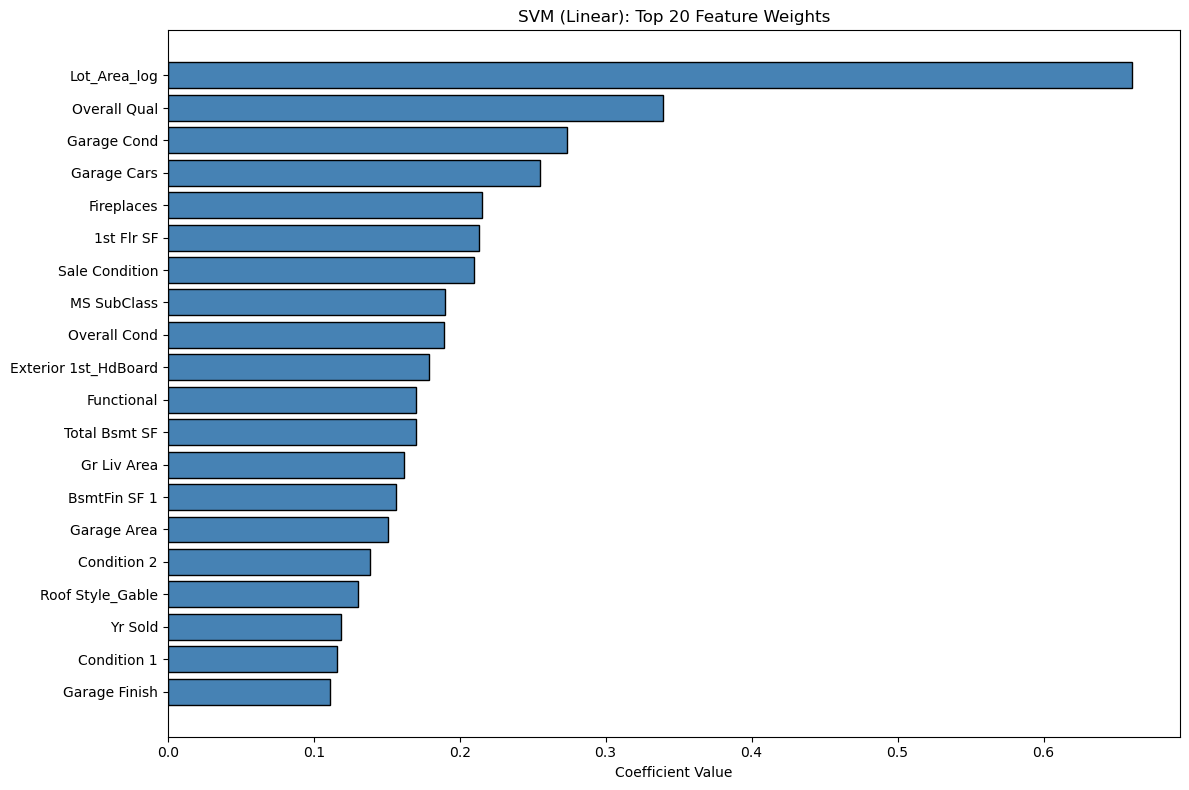

In [21]:
coef_svm = svm_model.coef_[0]
feature_names = X.columns

coef_df_svm = pd.DataFrame({'Feature': feature_names, 'Coefficient': coef_svm})
coef_df_svm = coef_df_svm.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(12, 8))
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df_svm['Coefficient'].head(20)]
plt.barh(coef_df_svm['Feature'].head(20), coef_df_svm['Coefficient'].head(20), color=colors, edgecolor='black')
plt.xlabel('Coefficient Value')
plt.title('SVM (Linear): Top 20 Feature Weights')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Model is too dependent in **Lot_Area_Log**


Ok , let's decrease C and increase max_iter

In [22]:
svm_model = SVC(C=0.1, kernel='linear', max_iter=2000)   
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

svm_performance = evaluate_binary_model("SVM (Linear)", y_test, y_pred_svm)

 SVM (Linear)          Accuracy : 0.9370 | Precision: 0.9247 | Recall : 0.9507 | F1 Score : 0.9375


c:\Users\kavoshrayan\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


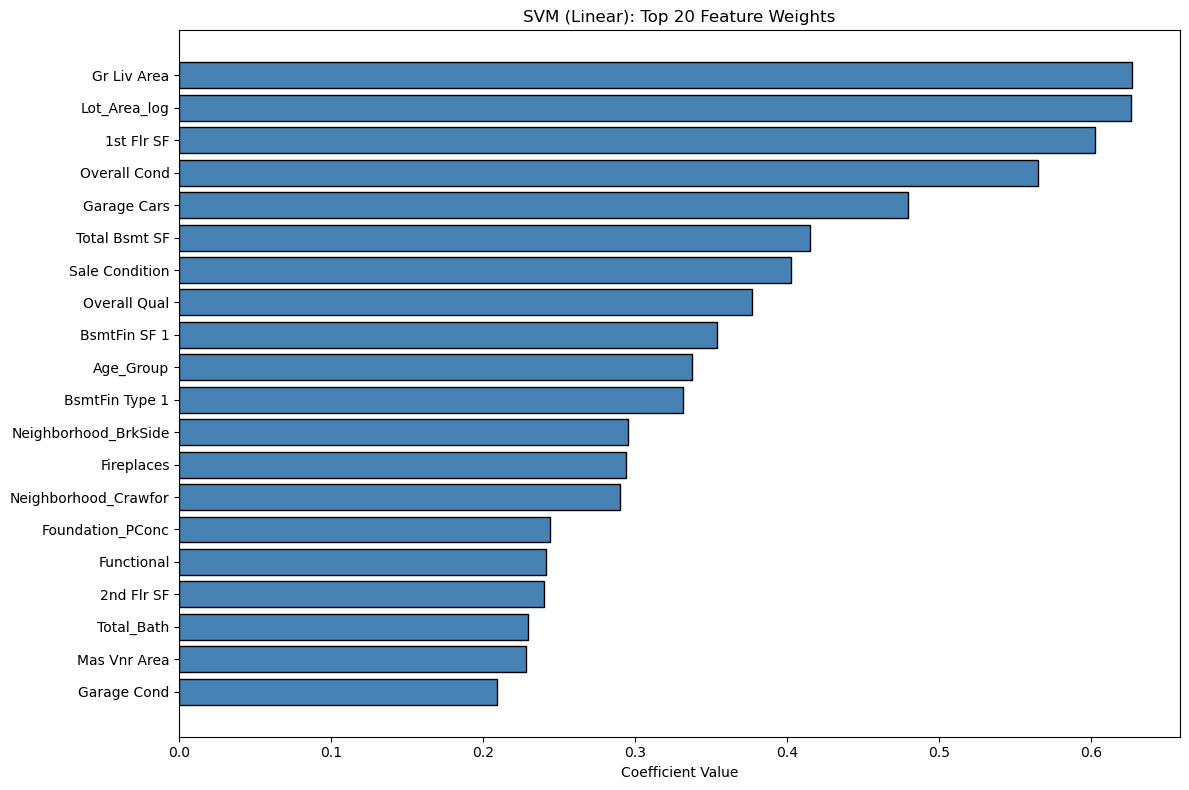

In [23]:
coef_svm = svm_model.coef_[0]
feature_names = X.columns

coef_df_svm = pd.DataFrame({'Feature': feature_names, 'Coefficient': coef_svm})
coef_df_svm = coef_df_svm.sort_values('Coefficient', ascending=False)

plt.figure(figsize=(12, 8))
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df_svm['Coefficient'].head(20)]
plt.barh(coef_df_svm['Feature'].head(20), coef_df_svm['Coefficient'].head(20), color=colors, edgecolor='black')
plt.xlabel('Coefficient Value')
plt.title('SVM (Linear): Top 20 Feature Weights')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The model's dependence on a specific feature was reduced and the weight distribution was improved.

Linear SVM achieved F1 = 0.93, same as  Logistic Regression (F1 = 0.94).  

## Kernel SVM

Linear models (Logistic Regression, Linear SVM) assume data is **linearly separable**.  
If the data is not linear (circular, curved patternsو ..), they fail.

The **kernel trick** solves this by **mapping data into a higher‑dimensional space** where it becomes linearly separable, without explicitly computing the transformation.

#### RBF Kernel
The RBF (Radial Basis Function) kernel measures **similarity** between two points:

K(x, x') = exp( -γ × ||x - x'||² )

In [29]:
k_svm_model = SVC(C=1, kernel='rbf', max_iter=100)
k_svm_model.fit(X_train, y_train)
y_pred_ksvm = k_svm_model.predict(X_test)

k_svm_performance = evaluate_binary_model("Kernel SVM (RBF)", y_test, y_pred_ksvm)

 Kernel SVM (RBF)      Accuracy : 0.8739 | Precision: 0.8786 | Recall : 0.8662 | F1 Score : 0.8723


c:\Users\kavoshrayan\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


##### Confusion Matrix on Kernel SVM (RBF)

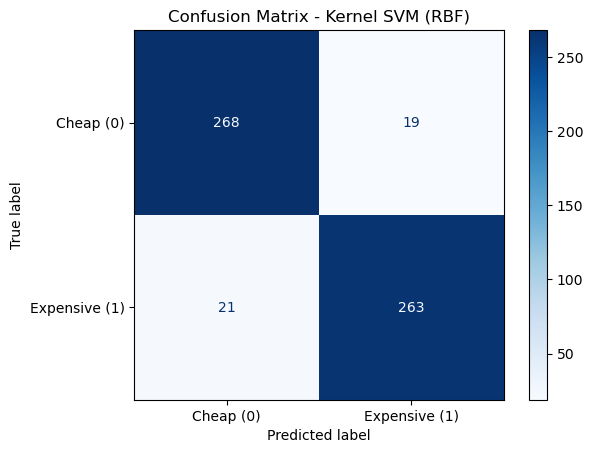

In [102]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_svm = confusion_matrix(y_test, y_pred_ksvm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Cheap (0)', 'Expensive (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Kernel SVM (RBF)')
plt.show()

The model is **slow** and achieved an F1 score of **0.87** 

We applied **PCA** to reduce the feature space to 10 components.

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10 , random_state=42)
X_train_pca = pca.fit_transform(X_train)  
X_test_pca = pca.transform(X_test)

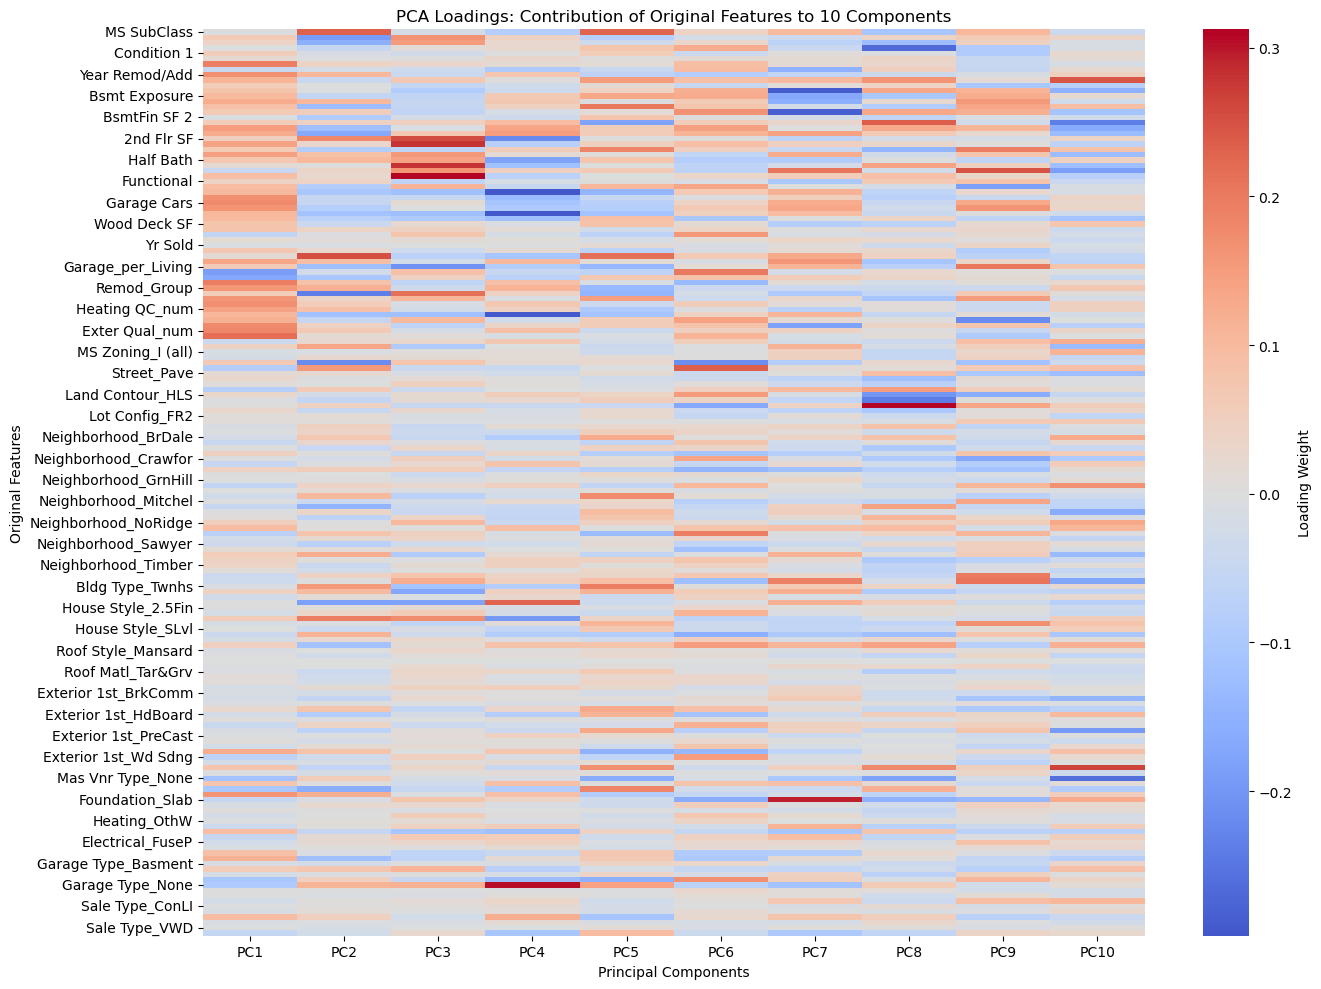

In [34]:
loadings = pca.components_.T 

component_names = [f"PC{i+1}" for i in range(loadings.shape[1])]

feature_names = X.columns

loadings_df = pd.DataFrame(
    loadings,
    index=feature_names,
    columns=component_names
)

plt.figure(figsize=(14, 10))
sns.heatmap(loadings_df.iloc[:, :], 
            cmap='coolwarm', 
            center=0,
            annot=False, 
            fmt='.2f',
            cbar_kws={'label': 'Loading Weight'})
plt.title('PCA Loadings: Contribution of Original Features to 10 Components')
plt.xlabel('Principal Components')
plt.ylabel('Original Features')
plt.tight_layout()
plt.show()

In [36]:
ksvm_pca_model = SVC(C=1, kernel='rbf', max_iter=100, random_state=42)
ksvm_pca_model.fit(X_train_pca, y_train)

y_pred_ksvm_pca = ksvm_pca_model.predict(X_test_pca)

ksvm_pca_performance = evaluate_binary_model("Kernel SVM (RBF, PCA)", y_test, y_pred_ksvm_pca)


 Kernel SVM (RBF, PCA)  Accuracy : 0.8704 | Precision: 0.8777 | Recall : 0.8592 | F1 Score : 0.8683


c:\Users\kavoshrayan\anaconda3\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


The model achieved F1 = 0.8683, which is **slightly lower** than the version without PCA, indicating that PCA removed some useful information.

Let's increase max_iter

In [37]:
ksvm_pca_model = SVC(C=1, kernel='rbf', max_iter=1000, random_state=42)
ksvm_pca_model.fit(X_train_pca, y_train)

y_pred_ksvm_pca = ksvm_pca_model.predict(X_test_pca)

ksvm_pca_performance = evaluate_binary_model("Kernel SVM (RBF, PCA)", y_test, y_pred_ksvm_pca)


 Kernel SVM (RBF, PCA)  Accuracy : 0.9440 | Precision: 0.9375 | Recall : 0.9507 | F1 Score : 0.9441


After applying PCA and increasing **max_iter** to 1000, the RBF‑kernel SVM achieved:

- **F1 Score**: 0.9441
- **Accuracy**: 0.9440
- **Precision**: 0.9375
- **Recall**: 0.9507

This performance is **almost identical** to Logistic Regression (F1 = 0.939), confirming that:
- The dataset is nearly linear.
- Both linear and non‑linear models perform equally well.
- Adding non‑linearity (RBF kernel) does not hurt but also does not significantly improve results.

### KNN

In [39]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

knn_performance = evaluate_binary_model("KNN", y_test, y_pred_knn)

 KNN                   Accuracy : 0.9054 | Precision: 0.9137 | Recall : 0.8944 | F1 Score : 0.9039


##### Tune to find the best number of neighbors (K)

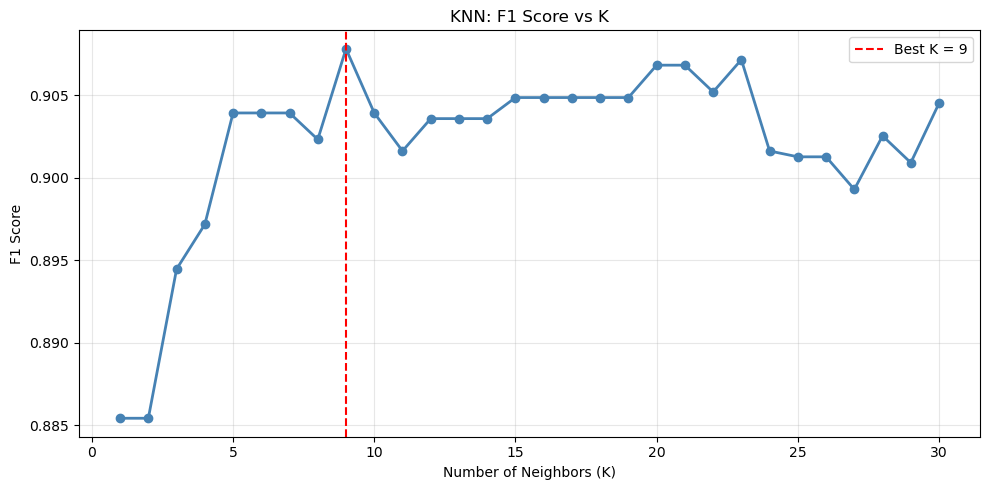

In [56]:
k_values = range(1, 31)
f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    f1_scores.append(f1_score(y_test, y_pred))

best_k = k_values[f1_scores.index(max(f1_scores))]
best_f1 = max(f1_scores)

# K vs F1 Score
plt.figure(figsize=(10, 5))
plt.plot(k_values, f1_scores, 'o-', color='steelblue', linewidth=2, markersize=6)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('F1 Score')
plt.title('KNN: F1 Score vs K')
plt.grid(True, alpha=0.3)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.legend()
plt.tight_layout()
plt.show()

We then tuned the number of neighbors (K) from 1 to 30.

- **Best K**: 9

In [42]:
knn_model = KNeighborsClassifier(n_neighbors=9, weights='distance')
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

knn_performance = evaluate_binary_model("KNN", y_test, y_pred_knn)

 KNN                   Accuracy : 0.9089 | Precision: 0.9143 | Recall : 0.9014 | F1 Score : 0.9078


- Logistic Regression achieved F1 = 0.94 
- KNN achieved F1 = 0.9

Logistic Regression still performs better, but KNN is a strong non‑parametric alternative.

### Decision Tree

In [53]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth= 10, random_state=42) 
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

dt_performance = evaluate_binary_model("Decision Tree", y_test, y_pred_dt)

 Decision Tree         Accuracy : 0.8914 | Precision: 0.8801 | Recall : 0.9049 | F1 Score : 0.8924


##### Tune for best max-depth to avoid overfitting

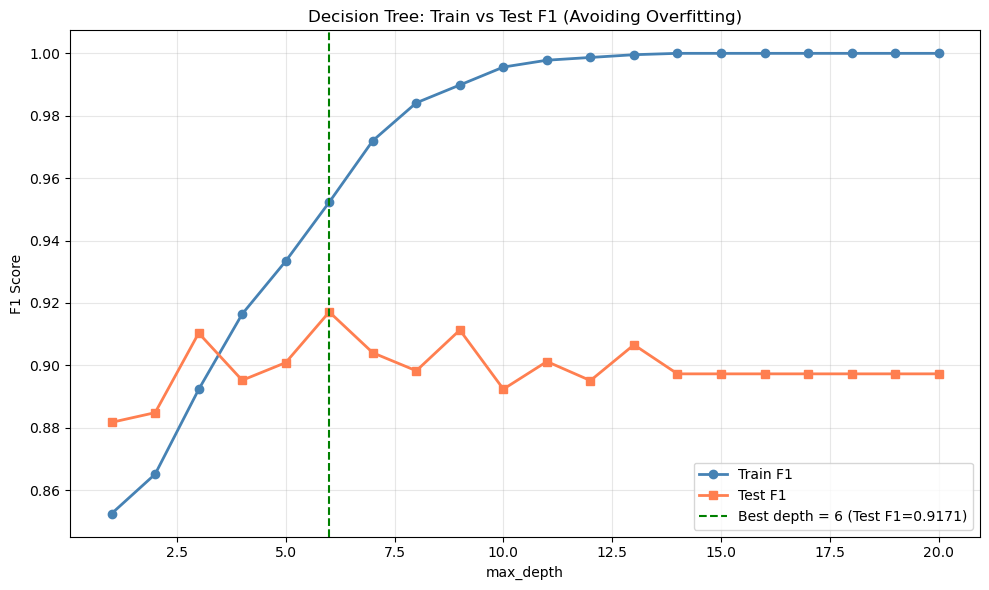

In [54]:
depths = range(1, 21)
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)

    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)
    
    train_scores.append(f1_score(y_train, y_train_pred))
    test_scores.append(f1_score(y_test, y_test_pred))

best_depth = depths[test_scores.index(max(test_scores))]
best_test_score = max(test_scores)

# Depth vs F1 Score
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'o-', label='Train F1', color='steelblue', linewidth=2, markersize=6)
plt.plot(depths, test_scores, 's-', label='Test F1', color='coral', linewidth=2, markersize=6)
plt.axvline(best_depth, color='green', linestyle='--', label=f'Best depth = {best_depth} (Test F1={best_test_score:.4f})')
plt.xlabel('max_depth')
plt.ylabel('F1 Score')
plt.title('Decision Tree: Train vs Test F1 (Avoiding Overfitting)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


We varied **max_depth** from 1 to 20 and plotted F1 scores for both **training** and **test** sets.

- **Best depth (6)**: Test F1 is maximized, train-test gap is small.
- **Overfitting (depth > 6)**: Train F1 keeps increasing, but test F1 plateaus or drops → model memorizes noise.

We selected **max_depth = 6** because it gives the best generalization without overfitting.

In [57]:
dt_model = DecisionTreeClassifier(max_depth= 6, random_state=42) 
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

dt_performance = evaluate_binary_model("Decision Tree", y_test, y_pred_dt)

 Decision Tree         Accuracy : 0.9177 | Precision: 0.9187 | Recall : 0.9155 | F1 Score : 0.9171


[Text(0.5193965517241379, 0.9285714285714286, 'Quality_Score <= 0.06\ngini = 0.5\nsamples = 2283\nvalue = [1146, 1137]'),
 Text(0.28448275862068967, 0.7857142857142857, 'Quality_Score <= -0.34\ngini = 0.272\nsamples = 1217\nvalue = [1019, 198]'),
 Text(0.4019396551724138, 0.8571428571428572, 'True  '),
 Text(0.13505747126436782, 0.6428571428571429, 'Total_Bath <= 0.077\ngini = 0.13\nsamples = 901\nvalue = [838, 63]'),
 Text(0.07471264367816093, 0.5, 'Neighborhood_NWAmes <= 2.167\ngini = 0.073\nsamples = 793\nvalue = [763, 30]'),
 Text(0.04597701149425287, 0.35714285714285715, '1st Flr SF <= 0.206\ngini = 0.06\nsamples = 777\nvalue = [753, 24]'),
 Text(0.022988505747126436, 0.21428571428571427, 'Neighborhood_Gilbert <= 1.886\ngini = 0.029\nsamples = 680\nvalue = [670, 10]'),
 Text(0.011494252873563218, 0.07142857142857142, 'gini = 0.026\nsamples = 678\nvalue = [669, 9]'),
 Text(0.034482758620689655, 0.07142857142857142, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.068965517241379

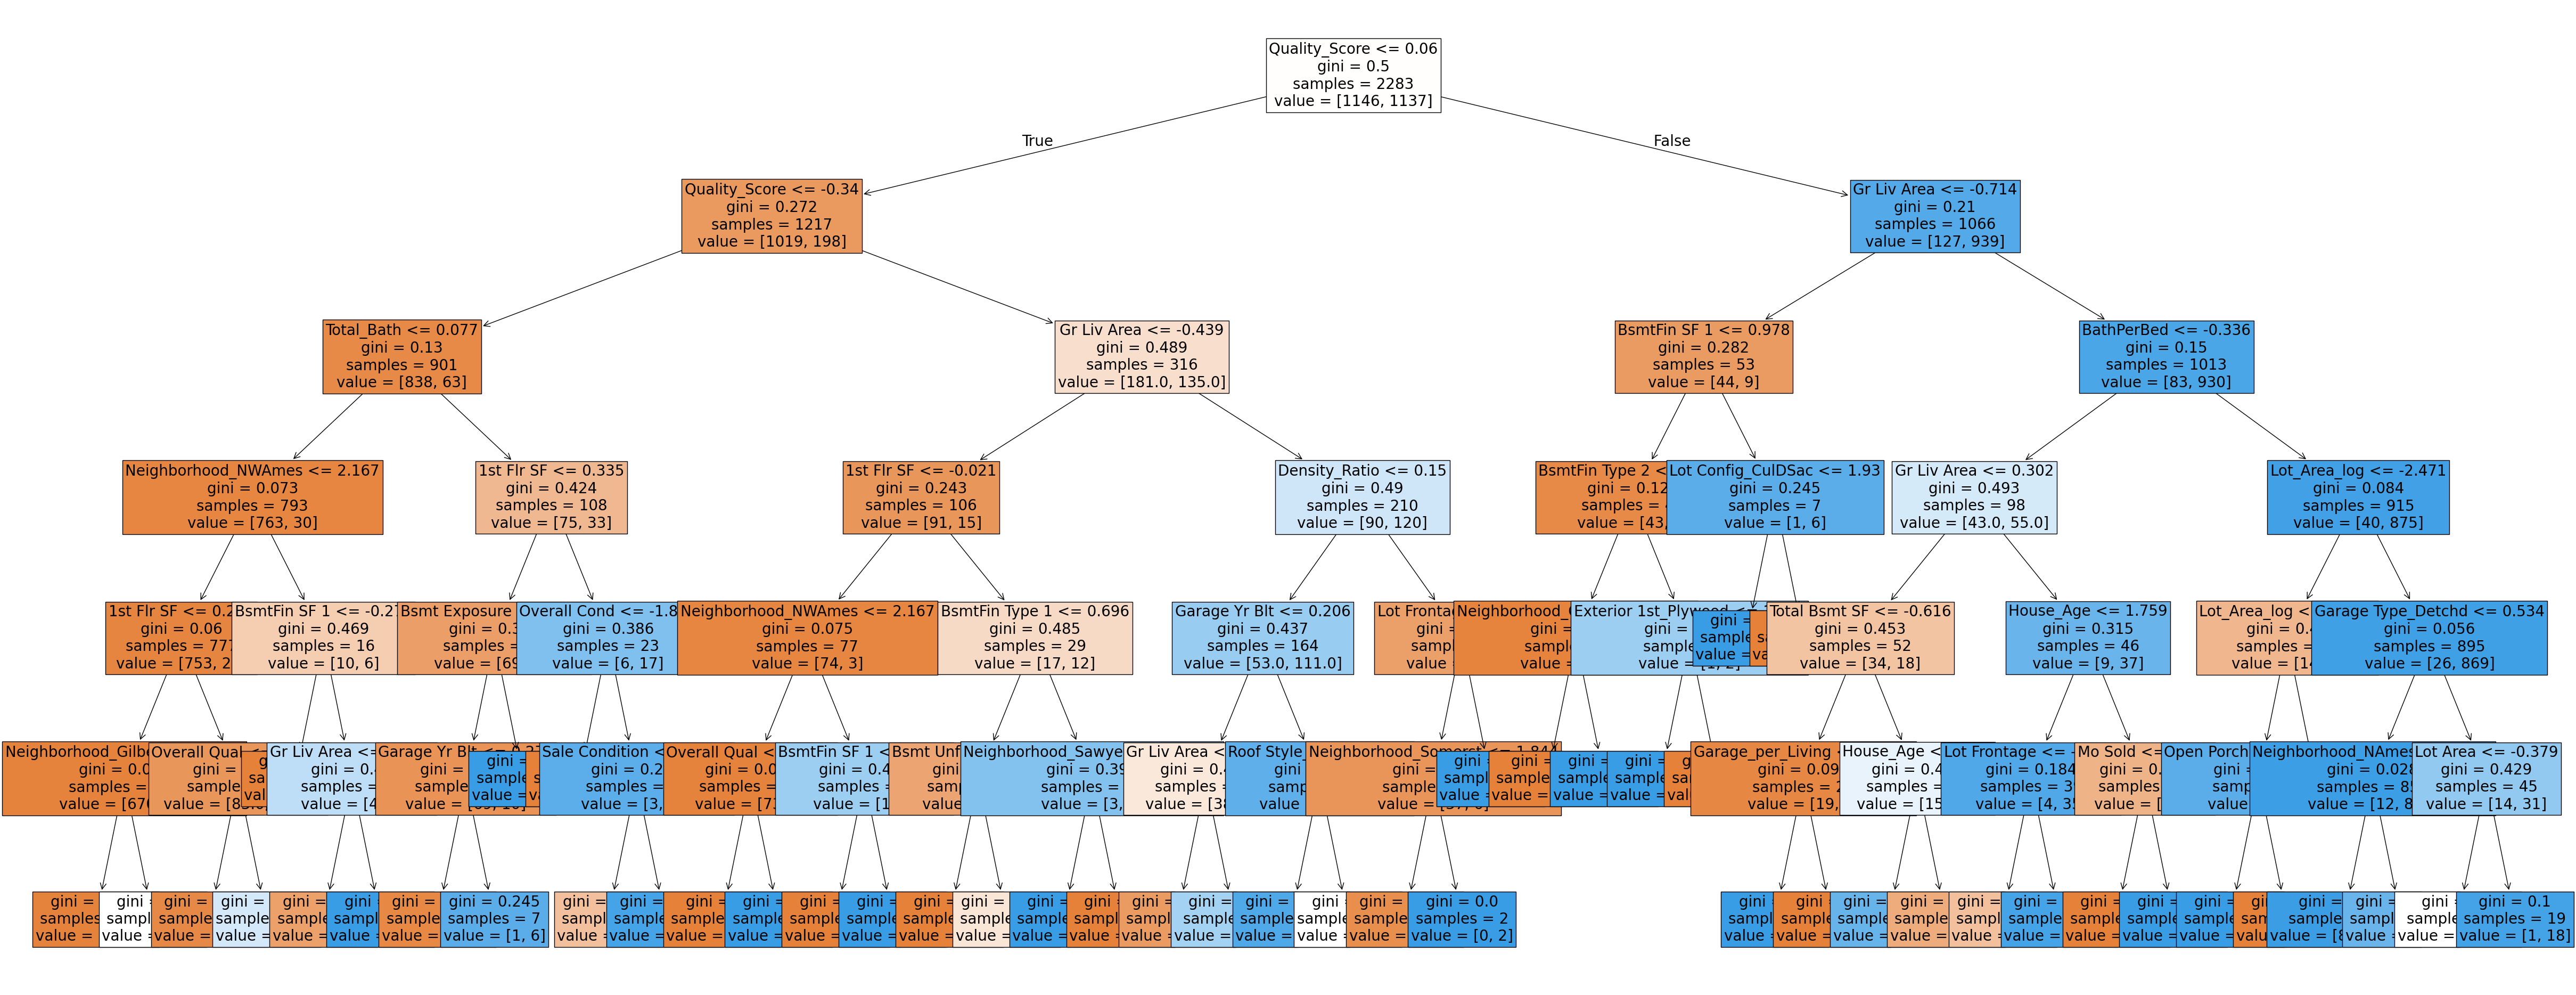

In [69]:
# visualing the final tree
from sklearn import tree

fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (60,24))
tree.plot_tree(dt_model, feature_names = X.columns, filled = True,fontsize=20)

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
rf_performance = evaluate_binary_model("Random Forest", y_test, y_pred_rf, y_proba_rf)

 Random Forest         Accuracy : 0.9229 | Precision: 0.9380 | Recall : 0.9049 | F1 Score : 0.9211
AUC   : 0.9768


##### Tuning the n_estimators (number of trees to bagging)

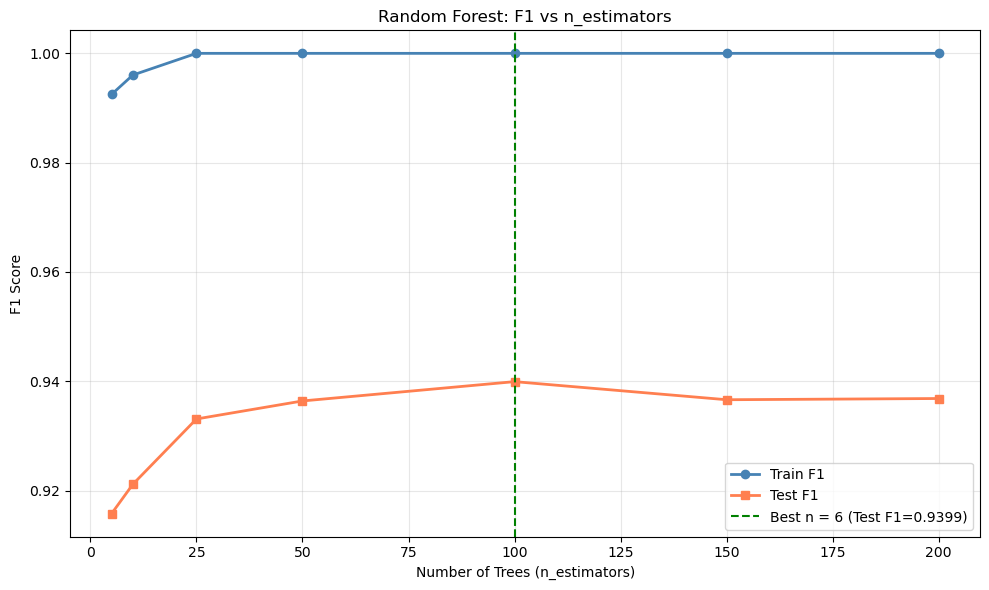

In [84]:
n_estimators = [5, 10, 25, 50, 100, 150, 200]
train_scores = []
test_scores = []

for n in n_estimators:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)
    
    train_scores.append(f1_score(y_train, y_train_pred))
    test_scores.append(f1_score(y_test, y_test_pred))

best_n = n_estimators[test_scores.index(max(test_scores))]
best_test_score = max(test_scores)

# n-stimators vs F1 Score
plt.figure(figsize=(10, 6))
plt.plot(n_estimators, train_scores, 'o-', label='Train F1', color='steelblue', linewidth=2, markersize=6)
plt.plot(n_estimators, test_scores, 's-', label='Test F1', color='coral', linewidth=2, markersize=6)
plt.axvline(best_n, color='green', linestyle='--', label=f'Best n = {best_depth} (Test F1={best_test_score:.4f})')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('F1 Score')
plt.title('Random Forest: F1 vs n_estimators')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- **Best n_estimators**: 100

Increasing trees beyond 100 does not improve test performance and only increases training time.  
We will use **n_estimators = 100** for the final model.

In [86]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
rf_performance = evaluate_binary_model("Random Forest", y_test, y_pred_rf, y_proba_rf)

 Random Forest         Accuracy : 0.9405 | Precision: 0.9433 | Recall : 0.9366 | F1 Score : 0.9399
AUC   : 0.9837


##### ROC Curve for Random Forest Model

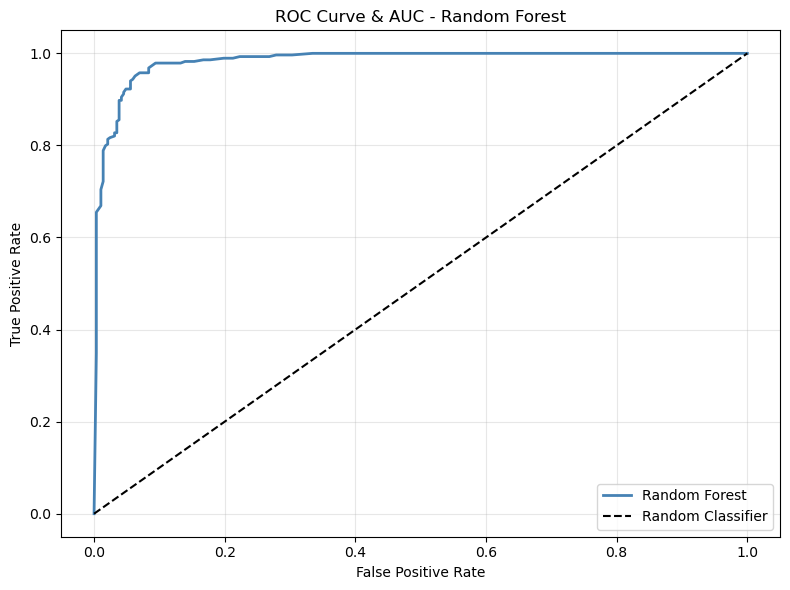

In [101]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='steelblue', linewidth=2, label=f'Random Forest')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve & AUC - Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Random Forest model achieves AUC = 0.9837 — excellent discriminative power. Nearly perfect separation between classes, far better than random classifier. No further improvement needed unless extreme sensitivity is required.

**Check feature importance of Decision Tree vs. Random Forest**

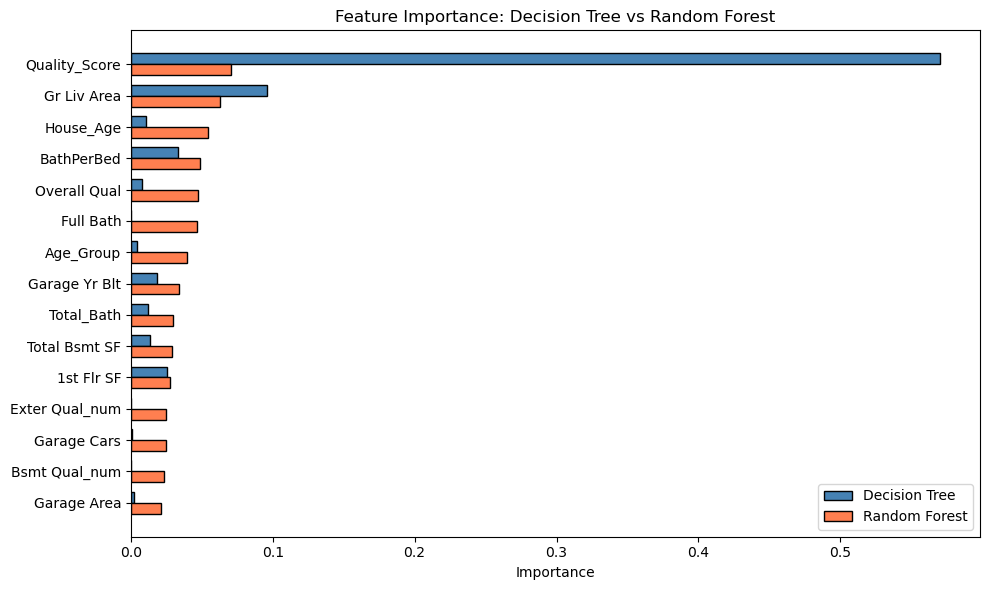

In [97]:
importance_dt = dt.feature_importances_
importance_rf = rf.feature_importances_

comp_df = pd.DataFrame({
    'Feature': X.columns,
    'Decision Tree': importance_dt,
    'Random Forest': importance_rf
})

comp_df = comp_df.sort_values('Random Forest', ascending=False)
top_features = comp_df.head(15)


fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(top_features['Feature']))
bar_height = 0.35

ax.barh(y_pos - bar_height/2, top_features['Decision Tree'], bar_height, label='Decision Tree', color='steelblue', edgecolor='black')
ax.barh(y_pos + bar_height/2, top_features['Random Forest'], bar_height, label='Random Forest', color='coral', edgecolor='black')

ax.set_yticks(y_pos)
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Importance')
ax.set_title('Feature Importance: Decision Tree vs Random Forest')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

- **Decision Tree**: a few features dominate (e.g., **Quality Score**, **Gr Liv Area**), others get near‑zero importance.
- **Random Forest**: importance is **more evenly distributed** across many features.

- A single tree can be **unstable** and over‑focus on a few features.
- Random Forest averages many trees → **more reliable, stable** importance scores.
- This plot clearly shows how ensemble learning smooths feature importance and reduces overfitting.


### Which model to choose?

- **Logistic Regression (C=0.01)**: F1 = 0.9399, AUC ≈0.9846
- **Random Forest**: F1 = 0.9399, AUC = 0.9837
- **Kernel SVM (RBF, PCA)**: F1 = 0.9441


| Criterion | Best Model |
|-----------|------------|
| Interpretability | Logistic Regression |
| Highest AUC | Random Forest |
| Speed | Logistic Regression |
| Non‑linear patterns | Random Forest |

**We choose Logistic Regression as the final model** because:
- **Almost identical performance** to Random Forest.
- **Much simpler** and **interpretable** (coefficients show direct impact of features).
- **Faster** to train and predict.
- The dataset is **almost linear**, so a non‑linear model (Random Forest) is not necessary.

However, Random Forest is a strong alternative if non‑linear interactions are important.

#### Best Classification Metric for This Dataset :

- The best metric for our dataset is F1 Score (and AUC as a close second).
**Why?**

- Our dataset has balanced classes (≈50% Cheap, ≈50% Expensive).
-We want to correctly identify expensive houses (high Recall).
- We also want to avoid misclassifying cheap houses as expensive (high Precision).
- F1 Score is the harmonic mean of Precision and Recall → balances both.
-Accuracy can be misleading if the dataset were imbalanced (but here it's balanced, so accuracy is also valid).

#### Three Techniques to Regularize Decision Trees :

1- Limit the maximum depth of the tree (max_depth), which prevents it from growing too deep and capturing noise.

2- Set a minimum number of samples required to split a node (min_samples_split), which ensures that a node is only split if it has enough samples, reducing overfitting.

3- Set a minimum number of samples required to be at a leaf node (min_samples_leaf), which forces the tree to have larger, more general leaves instead of memorizing individual data points.

#### Compare Linear SVM vs Kernel SVM :

- Linear SVM assumes that the data is linearly separable and finds a straight line (or hyperplane) as the decision boundary. It is fast, has only one main parameter (C), and is easy to interpret. However, it fails when the data has complex, non‑linear patterns.


- Kernel SVM, on the other hand, uses the kernel trick to map the data into a higher‑dimensional space where it becomes linearly separable. It can learn curved or complex decision boundaries, especially with the RBF kernel, but it has more parameters to tune (C and gamma), is slower, and is harder to interpret.